In [37]:
import requests
import pandas as pd
from datetime import datetime

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

BASE_URL = "https://api.openaq.org/v3"

In [38]:
lat = -23.6473149
lon = -46.6643635

url = f"{BASE_URL}/locations"

params = {
    "coordinates": f"{lat},{lon}",
    "radius": 5000,      # 5 km
    "limit": 100,
    "page": 1
}

r = requests.get(url, headers=headers, params=params)
r.raise_for_status()

data = r.json()
locations = pd.json_normalize(data["results"])

locations[[
    "id", "name", "coordinates.latitude", "coordinates.longitude",
    "datetimeFirst.utc", "datetimeLast.utc"
]].head()

,id,name,coordinates.latitude,coordinates.longitude,datetimeFirst.utc,datetimeLast.utc
0,5252,Congonhas,-23.616320,-46.663466,2017-08-10T23:00:00Z,2023-04-05T20:00:00Z
1,5278,Interlagos,-23.680508,-46.675043,2017-07-01T00:00:00Z,2023-04-05T20:00:00Z
2,5301,Santo Amaro,-23.654977,-46.709998,2017-07-01T00:00:00Z,2023-04-05T20:00:00Z
3,589967,Sao Paulo,-23.629158,-46.696558,2023-02-14T02:00:00Z,2025-03-04T12:00:00Z
4,6139516,São Paulo,-23.647315,-46.664364,2025-11-22T22:00:00Z,2026-06-09T11:00:00Z


In [39]:
location_id = 6139516

url = f"{BASE_URL}/locations/{location_id}/sensors"

r = requests.get(url, headers=headers)
r.raise_for_status()

sensors = pd.json_normalize(r.json()["results"])

sensors[[
    "id",
    "name",
    "parameter.name",
    "parameter.displayName",
    "parameter.units"
]]

,id,name,parameter.name,parameter.displayName,parameter.units
0,14700784,pm1 µg/m³,pm1,PM1,µg/m³
1,14700785,pm25 µg/m³,pm25,PM2.5,µg/m³
2,14700786,relativehumidity %,relativehumidity,RH,%
3,14700787,temperature c,temperature,Temperature (C),c
4,14700788,um003 particles/cm³,um003,PM0.3 count,particles/cm³


In [40]:
import requests
import pandas as pd

def baixa_sensor(sensor_id, date_from, date_to, api_key):

    headers = {
        "X-API-Key": api_key
    }

    base_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

    page = 1
    limit = 1000

    dados = []

    while True:

        params = {
            "datetime_from": date_from,
            "datetime_to": date_to,
            "limit": limit,
            "page": page
        }

        r = requests.get(base_url, headers=headers, params=params)
        r.raise_for_status()

        js = r.json()

        results = js.get("results", [])

        if len(results) == 0:
            break

        dados.extend(results)

        found = js.get("meta", {}).get("found", 0)

        if page * limit >= found:
            break

        page += 1

    df = pd.json_normalize(dados)

    return df

In [41]:
dfs = {}

for _, row in sensors.iterrows():

    sensor_id = row["id"]
    nome = row["parameter.name"]

    print(f"Baixando: {nome}")

    try:

        df_tmp = baixa_sensor(
            sensor_id=sensor_id,
            date_from="2026-04-22T00:00:00Z",
            date_to="2026-05-21T23:59:59Z",
            api_key=API_KEY
        )

        dfs[nome] = df_tmp

    except Exception as e:

        print(f"Erro em {nome}: {e}")

Baixando: pm1
Baixando: pm25
Baixando: relativehumidity
Baixando: temperature
Baixando: um003


In [42]:
import pandas as pd

# ==========================================
# ORGANIZA TODAS AS SÉRIES
# ==========================================

serie_final = pd.DataFrame()

for nome, df_tmp in dfs.items():

    if len(df_tmp) == 0:
        continue

    df_aux = pd.DataFrame()

    # tempo local
    df_aux["time"] = pd.to_datetime(
        df_tmp["period.datetimeFrom.local"]
    )

    # valor do sensor
    df_aux[nome] = df_tmp["value"]

    # índice temporal
    df_aux = df_aux.set_index("time")

    # remove duplicados se existirem
    df_aux = df_aux[~df_aux.index.duplicated(keep="first")]

    # junta no dataframe principal
    if serie_final.empty:

        serie_final = df_aux

    else:

        serie_final = serie_final.join(
            df_aux,
            how="outer"
        )

# ==========================================
# ORDENA PELO TEMPO
# ==========================================

serie_final = serie_final.sort_index()

# ==========================================
# SALVA CSV
# ==========================================

arquivo_saida = "../data/open_aq/openaq_estacao_6139516.csv"

serie_final.to_csv(
    arquivo_saida,
    sep=",",
    decimal=".",
    encoding="utf-8"
)

print(f"Arquivo salvo: {arquivo_saida}")

# ==========================================
# MOSTRA INFORMAÇÕES
# ==========================================

print("\nShape:")
print(serie_final.shape)

print("\nColunas:")
print(serie_final.columns)

print("\nPeríodo:")
print(serie_final.index.min())
print(serie_final.index.max())

serie_final.head()

Arquivo salvo: ../data/open_aq/openaq_estacao_6139516.csv

Shape:
(714, 5)

Colunas:
Index(['pm1', 'pm25', 'relativehumidity', 'temperature', 'um003'], dtype='object')

Período:
2026-04-21 21:00:00-03:00
2026-05-21 19:00:00-03:00


,pm1,pm25,relativehumidity,temperature,um003
time,,,,,
2026-04-21 21:00:00-03:00,2.5,4.4,55.0,20.6,380.0
2026-04-21 22:00:00-03:00,0.7,1.8,55.0,20.6,271.0
2026-04-21 23:00:00-03:00,0.7,2.5,56.0,20.3,284.0
2026-04-22 00:00:00-03:00,0.9,2.6,57.0,20.1,282.0
2026-04-22 01:00:00-03:00,0.1,1.2,58.0,19.9,222.0


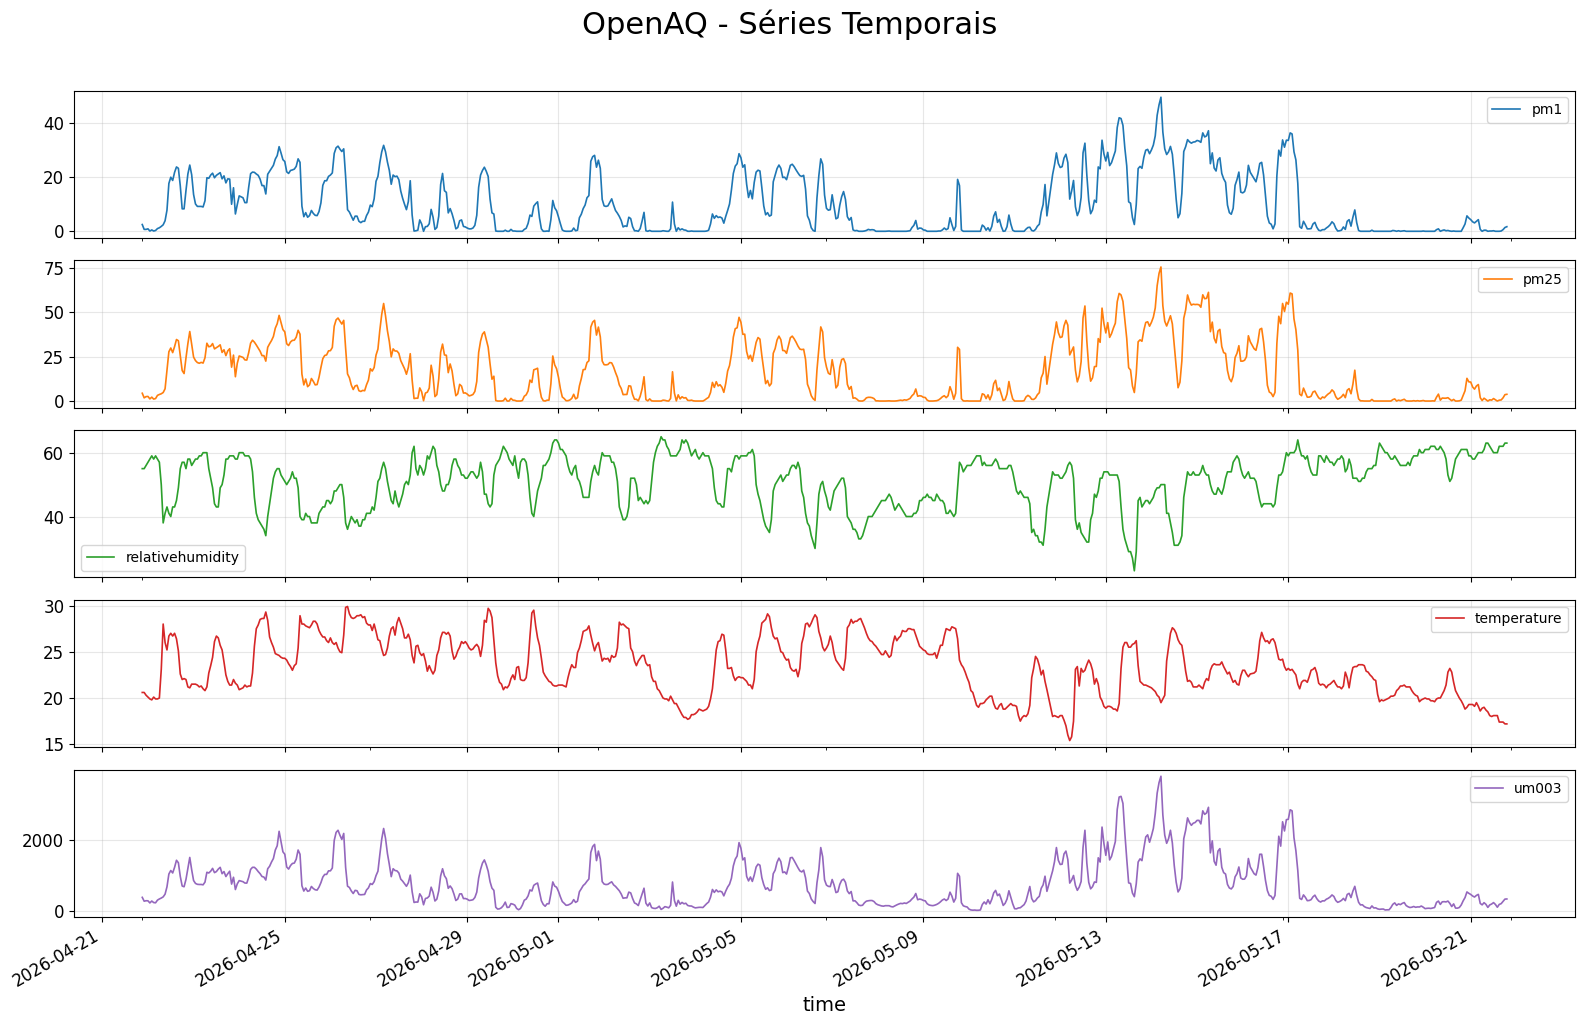

In [43]:
import matplotlib.pyplot as plt

# ==========================================
# PLOT COM FONTES MAIORES
# ==========================================

axes = serie_final.plot(
    figsize=(16,10),
    subplots=True,
    sharex=True,
    linewidth=1.2,
    fontsize=12   # números dos eixos
)

# título geral
plt.suptitle(
    "OpenAQ - Séries Temporais",
    fontsize=22,
    y=1.02
)

# ajusta cada subplot
for ax in axes:

    # título de cada variável
    ax.set_title(
        ax.get_title(),
        fontsize=16
    )

    # labels dos eixos
    ax.set_ylabel(
        ax.get_ylabel(),
        fontsize=14
    )

    ax.set_xlabel(
        ax.get_xlabel(),
        fontsize=14
    )

    # tamanho dos ticks
    ax.tick_params(
        axis='both',
        labelsize=12
    )

    # grid mais suave
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### COMPARAÇÃO COM A ESTAÇÃO DA CETESB MAIS PRÓXIMA

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# COMPARAÇÃO OPENAQ x CETESB - CONGONHAS
# ============================================================

arquivo_cetesb = "../data/cetesb_site/Congonhas_2025_2026.csv"

# 1. Ler CETESB
df_cetesb = pd.read_csv(
    arquivo_cetesb,
    sep=";",
    encoding="latin1",
    skiprows=8,
    header=None,
    names=["Data", "Hora", "CO", "PM10", "PM25"],
    decimal=","
)

# 2. Criar datetime
df_cetesb["datetime"] = pd.to_datetime(
    df_cetesb["Data"].astype(str) + " " + df_cetesb["Hora"].astype(str),
    dayfirst=True,
    errors="coerce"
)

df_cetesb = df_cetesb.dropna(subset=["datetime"])
df_cetesb = df_cetesb.set_index("datetime").sort_index()

# 3. Garantir colunas numéricas
for col in ["CO", "PM10", "PM25"]:
    df_cetesb[col] = pd.to_numeric(df_cetesb[col], errors="coerce")

# 4. Preparar CETESB
df_cetesb_comp = df_cetesb[["PM25", "PM10"]].copy()
df_cetesb_comp.columns = ["pm25_cetesb", "pm10_cetesb"]

# 5. Preparar OpenAQ
df_openaq_comp = serie_final[["pm25", "pm1"]].copy()
df_openaq_comp.columns = ["pm25_openaq", "pm1_openaq"]

# Remover timezone da OpenAQ, se existir
if df_openaq_comp.index.tz is not None:
    df_openaq_comp.index = df_openaq_comp.index.tz_convert(None)

# Garantir índice datetime sem timezone na CETESB também
df_cetesb_comp.index = pd.to_datetime(df_cetesb_comp.index)

# 6. Juntar pelo tempo
df_comp = pd.concat([df_openaq_comp, df_cetesb_comp], axis=1)

# 7. Manter apenas período comum com PM2.5 nos dois sensores
df_comp = df_comp.dropna(subset=["pm25_openaq", "pm25_cetesb"])

print("Período comum:")
print(df_comp.index.min())
print(df_comp.index.max())

print("\nShape comparação:")
print(df_comp.shape)

df_comp.head()

Período comum:
2026-04-22 01:00:00
2026-05-21 22:00:00

Shape comparação:
(653, 4)


,pm25_openaq,pm1_openaq,pm25_cetesb,pm10_cetesb
2026-04-22 01:00:00,1.8,0.7,11.0,18.0
2026-04-22 02:00:00,2.5,0.7,10.0,13.0
2026-04-22 03:00:00,2.6,0.9,7.0,13.0
2026-04-22 04:00:00,1.2,0.1,11.0,13.0
2026-04-22 05:00:00,2.2,0.5,8.0,17.0


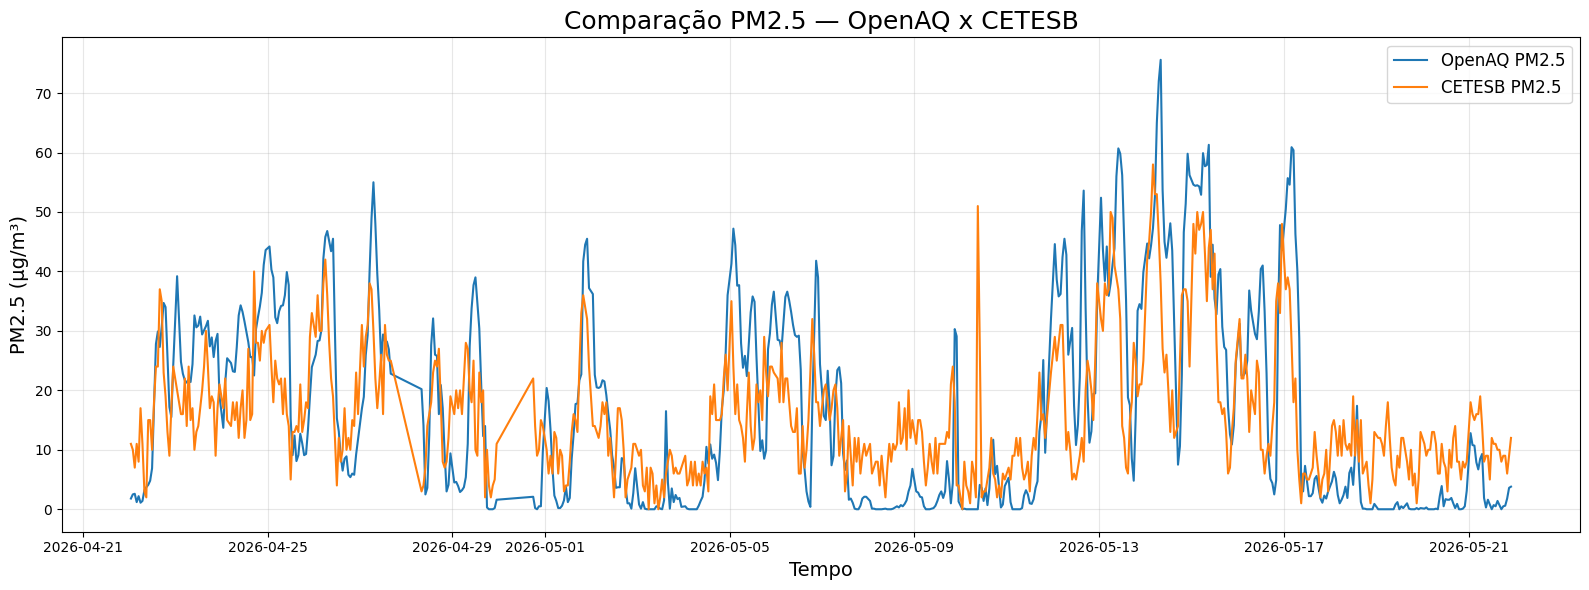

In [45]:
# ============================================================
# GRÁFICO 1 — PM2.5 OPENAQ x CETESB
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    df_comp.index,
    df_comp["pm25_openaq"],
    label="OpenAQ PM2.5",
    linewidth=1.5
)

plt.plot(
    df_comp.index,
    df_comp["pm25_cetesb"],
    label="CETESB PM2.5",
    linewidth=1.5
)

plt.title("Comparação PM2.5 — OpenAQ x CETESB", fontsize=18)
plt.xlabel("Tempo", fontsize=14)
plt.ylabel("PM2.5 (µg/m³)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
corr = df_comp[["pm25_openaq", "pm25_cetesb"]].corr().iloc[0, 1]
mae = mean_absolute_error(df_comp["pm25_cetesb"], df_comp["pm25_openaq"])
bias = (df_comp["pm25_openaq"] - df_comp["pm25_cetesb"]).mean()

print(f"Correlação: {corr:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Bias OpenAQ - CETESB: {bias:.2f}")

Correlação: 0.71
MAE: 9.56
Bias OpenAQ - CETESB: 0.92
